In [1]:
import numpy as np
import struct
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeClassifier, RidgeClassifierCV
from sklearn.model_selection import cross_val_score

from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.neighbors import KNeighborsClassifier

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC


## IMPORT DATA

In [3]:
# import data using hwhelper code

with open('/Users/jadeg/Documents/UW/winter/AMATH 582/HW3/data/train-images.idx3-ubyte','rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    nrows, ncols = struct.unpack(">II", f.read(8))
    data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    print(data.shape)
    Xtraindata = np.transpose(data.reshape((size, nrows*ncols)))

with open('/Users/jadeg/Documents/UW/winter/AMATH 582/HW3/data/train-labels.idx1-ubyte','rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    ytrainlabels = data.reshape((size,)) # (Optional)

with open('/Users/jadeg/Documents/UW/winter/AMATH 582/HW3/data/t10k-images.idx3-ubyte','rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    nrows, ncols = struct.unpack(">II", f.read(8))
    data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    Xtestdata = np.transpose(data.reshape((size, nrows*ncols)))

with open('/Users/jadeg/Documents/UW/winter/AMATH 582/HW3/data/t10k-labels.idx1-ubyte','rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    ytestlabels = data.reshape((size,)) # (Optional)
        

    
traindata_imgs =  np.transpose(Xtraindata).reshape((60000,28,28))    
print(Xtraindata.shape)
print(ytrainlabels.shape)
print(Xtestdata.shape)
print(ytestlabels.shape)
print(type(ytrainlabels))

(47040000,)
(784, 60000)
(60000,)
(784, 10000)
(10000,)
<class 'numpy.ndarray'>


## TASK 1
### Define Variables

In [3]:
# define vars

num_samps_tr = 60000
img_axsize_tr = 28
num_feats_tr = img_axsize_tr**2

### Plot First 64 Training Images

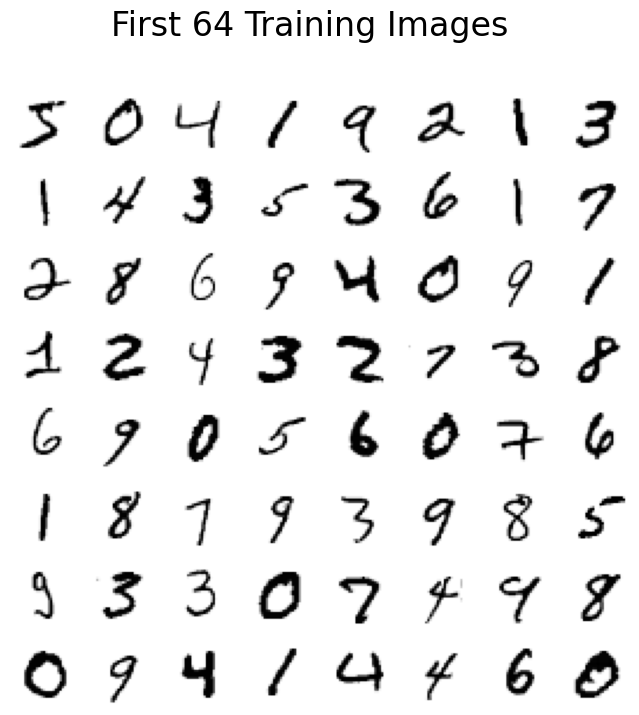

In [43]:
# from helper - plot first 64 images

def plot_digits(XX, N, title):
    fig, ax = plt.subplots(N, N, figsize=(8, 8))
    
    for i in range(N):
      for j in range(N):
        ax[i,j].imshow(XX[:,(N)*i+j].reshape((28, 28)), cmap="Greys")
        ax[i,j].axis("off")
    fig.suptitle(title, fontsize=24)

plot_digits(Xtraindata, 8, "First 64 Training Images" )
plt.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW3/Figures/first64_tr_imgs.png')

### Apply PCA with full SVD

In [50]:
# do PCA of each digit image

# apply PCA with full SVD
pca = PCA()
X_pca_tr = pca.fit_transform(Xtraindata.T) #reduce dimensions



### Pull modes and plot first 16 modes

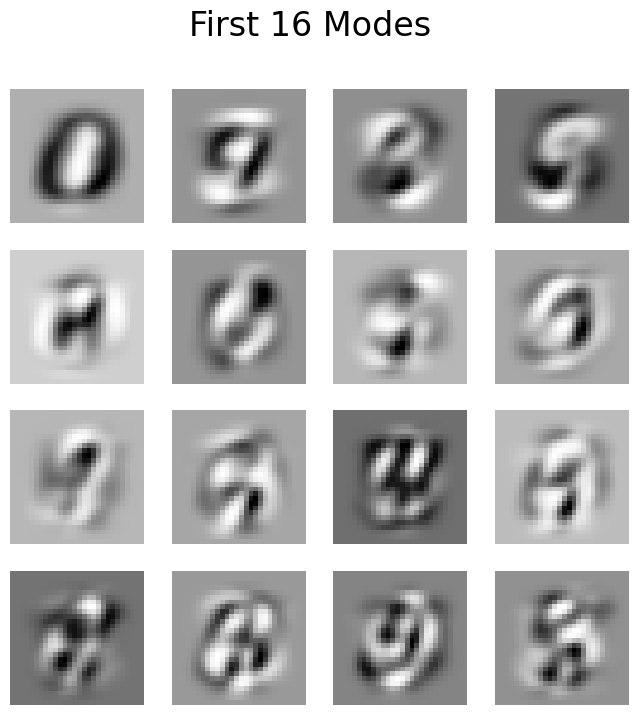

In [6]:
# pull out pc modes and plot the first 16

modes = pca.components_

plot_digits(modes.T, 4, "First 16 Modes")
plt.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW3/Figures/first16mod_imgs.png')

### Inspect cumulative energy and determine k needed for 85%

59


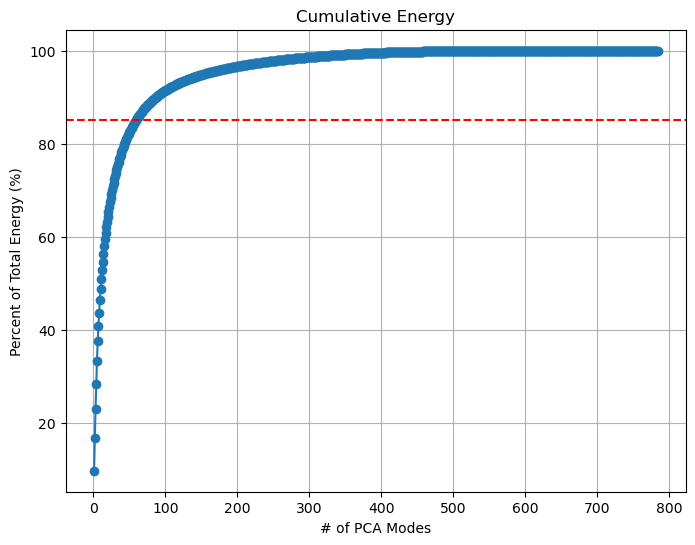

In [51]:
# inspect cumulative energy and determine k needed for 85%

# pull out singular values to calculate norm
S = pca.singular_values_
norm_full = (np.sum(S**2))

# plot the cumulative energy of K=1:num_feats (784)
x = np.arange(1,num_feats_tr+1)
y = np.zeros(num_feats_tr)
j = 0

# initialize K_85, once the energy passes 85% then save that K value as K_85
K_85 = 0
for K in x:
    S_n = S[0:K]
    norm_approx = (np.sum(S_n**2)) 
    y[j] = (norm_approx/norm_full) * 100
    if y[j] >= 85:
        if K_85==0:
            K_85 = K
    j+= 1
print(K_85)

# plot cumulative energy
plt.figure(figsize=(8,6))

plt.plot(x,y,'o-')
plt.grid()

# add lines are percents in problem statement
percs = [85]
for perc in percs:
    plt.axhline(y=perc, color='r', linestyle='--')

plt.xlabel('# of PCA Modes')

plt.ylabel('Percent of Total Energy (%)')
plt.title('Cumulative Energy')
#plt.xlim([0,15])
#plt.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW3/ZoomedCumEnergy.png')
plt.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW3/Figures/CumEnergy.png')

### Plot Images with K value needed for 85% (K=59)

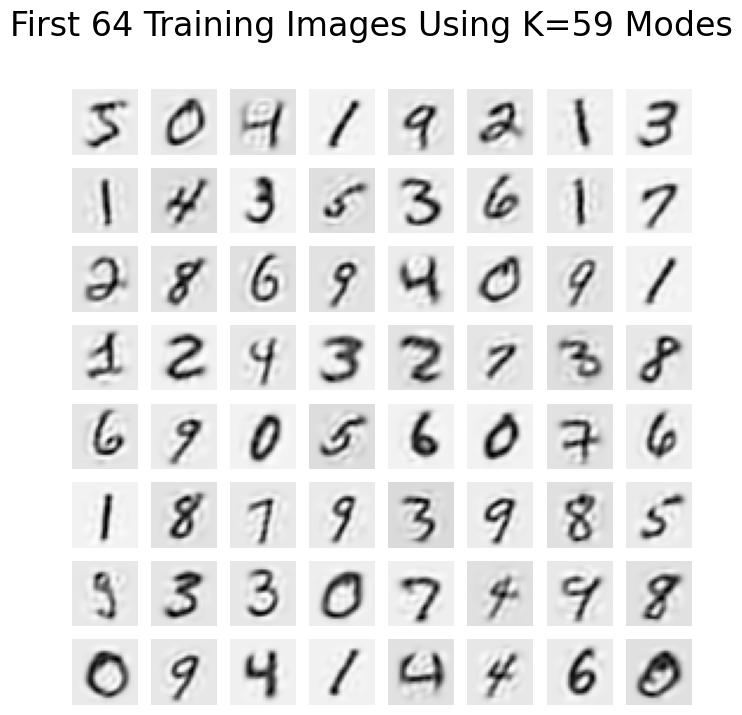

In [52]:
# plot images with K_85 to see how it looks
pca_K85 = PCA(n_components=K_85)
Xtr_pca_K = pca_K85.fit_transform(Xtraindata.T)
X_K85 = pca_K85.inverse_transform(Xtr_pca_K)

plot_digits(X_K85.T, 8, "First 64 Training Images Using K=59 Modes" )
plt.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW3/Figures/first64_K59_imgs.png')

## Apply K=59 transform to test data

In [9]:
Xte_pca_K = pca_K85.transform(Xtestdata.T)

### Test values K=10,50,100 and Plot them

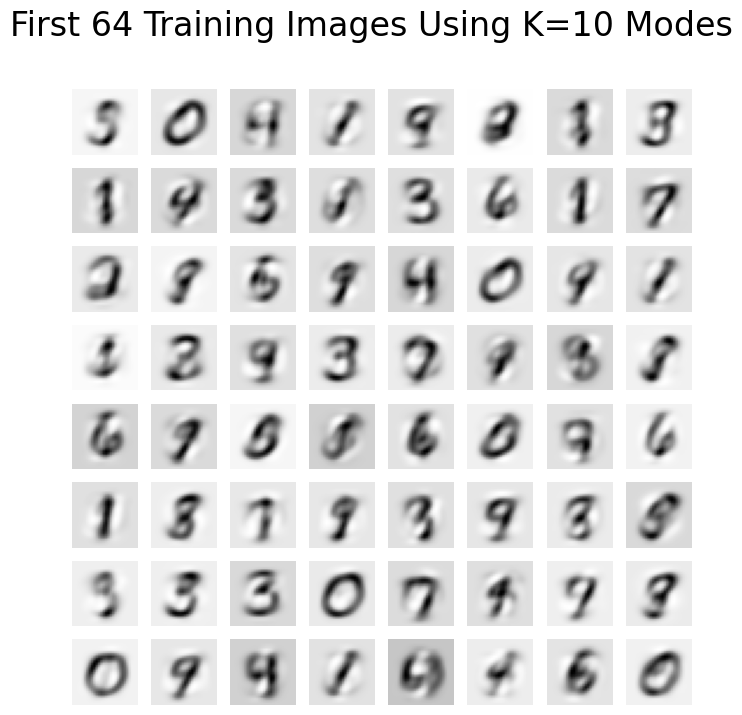

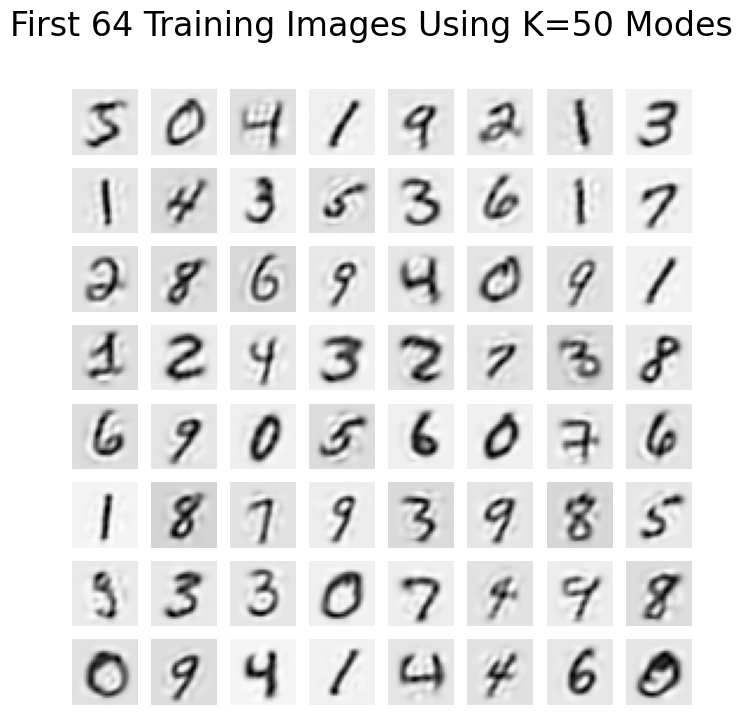

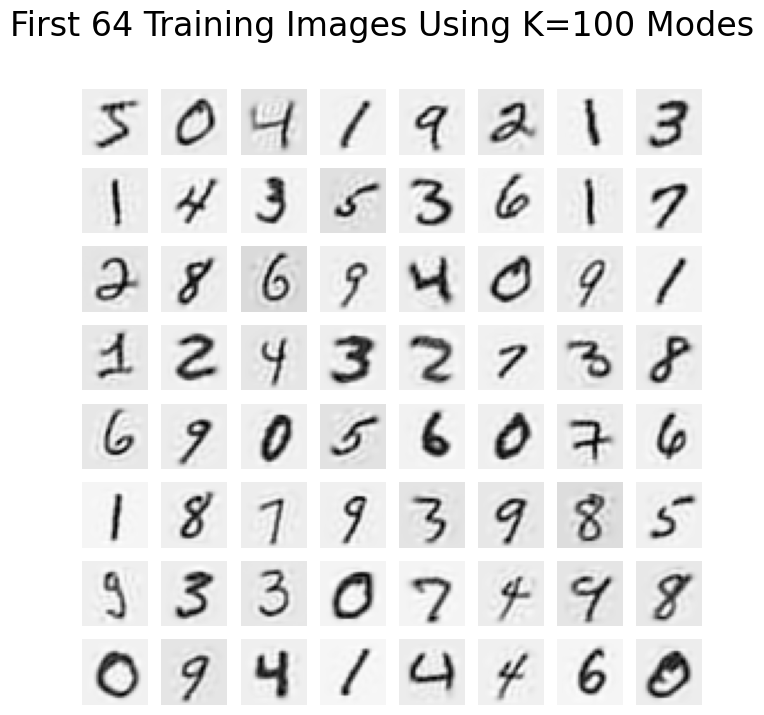

In [10]:
# plot images with K = 10, 50, 100 to see how it looks

for K in [10,50,100]:
    pca_K = PCA(n_components=K)
    Xtr_pca_K = pca_K.fit_transform(Xtraindata.T)
    X_K = pca_K.inverse_transform(Xtr_pca_K)

    plot_digits(X_K.T, 8, f"First 64 Training Images Using K={K} Modes" )
    plt.savefig(f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW3/Figures/first64_K{K}_imgs.png')

## TASK 3
### Write function that selects subset of particular digits

In [11]:
# task 3 - write a function that selects a subset of particular digits from x_tr, y_tr, x_te, y_te and 
# returns subsets as new matrices xsubtr, ysubtr, xsubte, ysubte

def subsetdig_fxn(Xtr,Ytr,Xte,Yte,digits):
    # isin returns boolean for where digits are in ytrainlabels, repeat for ytestlabels
    tr_i = np.where(np.isin(Ytr, digits))[0]
    te_i = np.where(np.isin(Yte, digits))[0]

    # pull out values from xtr,xte,ytr,yte using these indices
    X_subtr = Xtr[:,tr_i]
    X_subte = Xte[:,te_i]
    Y_subtr = Ytr[tr_i]
    Y_subte = Yte[te_i]

    return X_subtr,X_subte,Y_subtr,Y_subte

## TASK 4
### run ridge classification and scikit cross validation with various alphas and plot alphas vs accuracy

For [1, 8], using ridge score, the score of the training set is 0.9664893194631938
For [1, 8] & alpha=0.001, the cross validation mean of the training set is 0.9641867163016199 with an std of 0.002682411104531951
For [1, 8], using ridge score, the score of the testing set is 0.9772403982930299
For [1, 8], using ridge score, the score of the training set is 0.9664893194631938
For [1, 8] & alpha=0.0011497569953977356, the cross validation mean of the training set is 0.9641867163016199 with an std of 0.002682411104531951
For [1, 8], using ridge score, the score of the testing set is 0.9772403982930299
For [1, 8], using ridge score, the score of the training set is 0.9664893194631938
For [1, 8] & alpha=0.0013219411484660286, the cross validation mean of the training set is 0.9641867163016199 with an std of 0.002682411104531951
For [1, 8], using ridge score, the score of the testing set is 0.9772403982930299
For [1, 8], using ridge score, the score of the training set is 0.9664893194631938


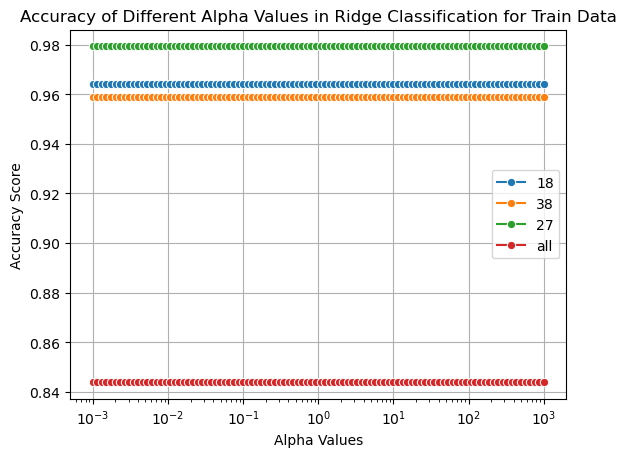

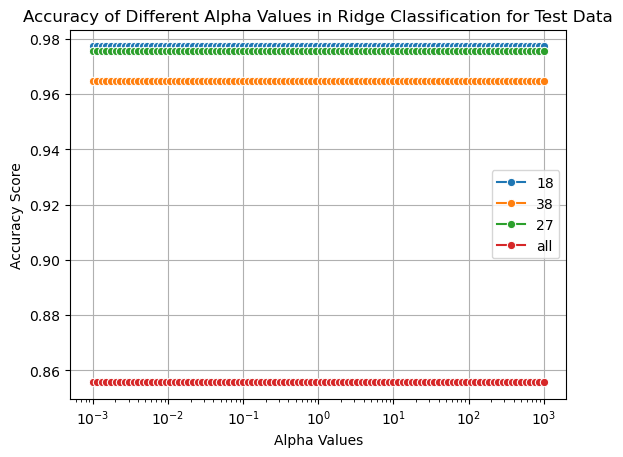

In [29]:
# Run ridge classification and scikit cross validation with 1&8, 3&8, 2&7, and all the values
# test different alpha values

digits_set = [[1,8],[3,8],[2,7],[0,1,2,3,4,5,6,7,8,9]]
digit_names = [18,38,27,'all']
alphas = np.logspace(-3, 3, 100)  
allscores_tr_array = np.empty((len(digits_set), len(alphas)))
allscores_te_array = np.empty((len(digits_set), len(alphas)))
for j, digits in enumerate(digits_set):
    for i, alpha in enumerate(alphas):
        # use fxn to pull out values for the digits
        X_subtr, X_subte, Y_subtr, Y_subte = subsetdig_fxn(Xtraindata,ytrainlabels,Xtestdata,ytestlabels,digits)

        # project data onto K-PC (29) modes
        Xsubtr_pca_K = pca_K85.transform(X_subtr.T)

        # make ridge classifier and fit
        RidgeCL = RidgeClassifier(alpha=alpha)
        RidgeCL.fit(Xsubtr_pca_K, Y_subtr)
        

        # use scikit cross validation to get score, cv=5 is standard
        scores_tr = cross_val_score(RidgeCL, Xsubtr_pca_K, Y_subtr, cv=5)

        # find mean and std
        scoremean_tr = scores_tr.mean()
        scorestd_tr = scores_tr.std()
        print(f'For {digits} & alpha={alpha}, the cross validation mean of the training set is {scoremean_tr} with an std of {scorestd_tr}')
        allscores_tr_array[j, i] = scoremean_tr
    

plt.figure()
for i in range(len(allscores_tr_array)):
    sns.lineplot(x=alphas, y=allscores_tr_array[i,:], marker='o', label=digit_names[i])
plt.xscale("log")
plt.xlabel("Alpha Values")
plt.ylabel("Accuracy Score")
plt.title(f"Accuracy of Different Alpha Values in Ridge Classification for Train Data")
plt.legend()
plt.grid()
plt.savefig(f"/Users/jadeg/Documents/UW/winter/AMATH 582/HW3/Figures/Alphatest_Rclass_tr.png")


### Use ridge class CV, make confusion matrix for when we're pulling out pairs of digits

alpha = 1.0
For [1, 8], using ridge score, the score of the training set is 0.966409910267609
For [1, 8] & alpha=1000.0, the cross validation mean of the training set is 0.9641867478332268 with an std of 0.0027401088314552456
For [1, 8], using ridge score, the score of the testing set is 0.9777145566619251
alpha = 1.0
For [3, 8], using ridge score, the score of the training set is 0.9604406609914873
For [3, 8] & alpha=1000.0, the cross validation mean of the training set is 0.9590225817887272 with an std of 0.006249026220129123
For [3, 8], using ridge score, the score of the testing set is 0.9652217741935484
alpha = 1.0
For [2, 7], using ridge score, the score of the training set is 0.9804466988464371
For [2, 7] & alpha=1000.0, the cross validation mean of the training set is 0.9797104214151597 with an std of 0.0018761489744772706
For [2, 7], using ridge score, the score of the testing set is 0.9766990291262136


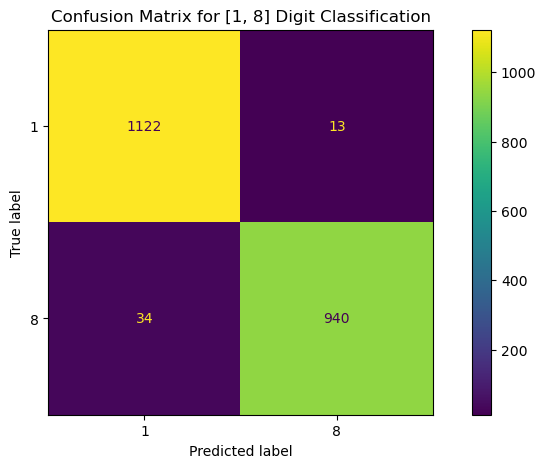

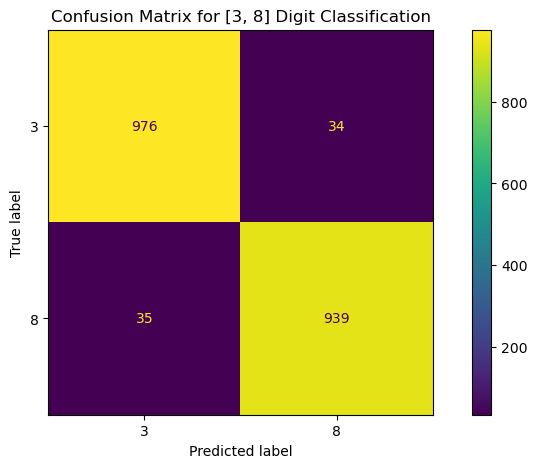

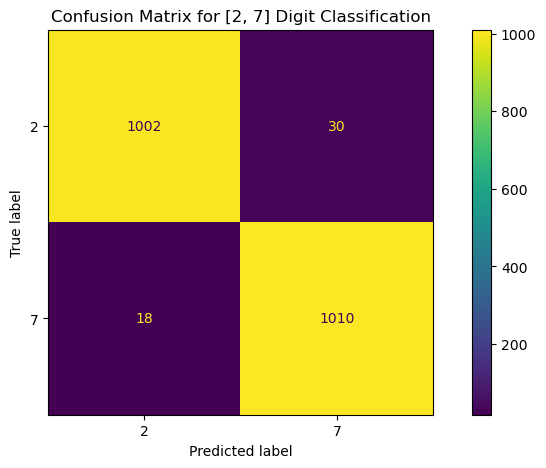

In [53]:
digits_set = [[1,8],[3,8],[2,7]]
alphas = np.logspace(-3, 0, 100)  
meanscores_array = np.array([])
meanstd_array = np.array([])

for digits in digits_set:
    # use fxn to pull out values for the digits
    X_subtr, X_subte, Y_subtr, Y_subte = subsetdig_fxn(Xtraindata,ytrainlabels,Xtestdata,ytestlabels,digits)

    # project data onto K-PC (59) modes
    Xsubtr_pca_K = pca_K85.transform(X_subtr.T)

    # make ridge classifier and fit
    RidgeCL = RidgeClassifierCV(alphas=alphas)
    RidgeCL.fit(Xsubtr_pca_K, Y_subtr)
    print(f'alpha = {RidgeCL.alpha_}')

    # use ridge classifier score as a check for training
    ridgescore_tr = RidgeCL.score(Xsubtr_pca_K, Y_subtr)
    print(f'For {digits}, using ridge score, the score of the training set is {ridgescore_tr}')

    # use scikit cross validation to get score, cv=5 is standard
    scores_tr = cross_val_score(RidgeCL, Xsubtr_pca_K, Y_subtr, cv=5)
    

    # find mean and std
    scoremean_tr = scores_tr.mean()
    scorestd_tr = scores_tr.std()
    print(f'For {digits} & alpha={alpha}, the cross validation mean of the training set is {scoremean_tr} with an std of {scorestd_tr}')
    meanscores_array = np.append(meanscores_array,scoremean_tr)
    meanstd_array = np.append(meanstd_array,scorestd_tr)

    # project data onto K-PC (29) modes
    Xsubte_pca_K = pca_K85.transform(X_subte.T)

    # fit ridge classifier
    RidgeCL.fit(Xsubte_pca_K, Y_subte)

    # use ridge classifier score as a check for testing
    ridgescore_te = RidgeCL.score(Xsubte_pca_K, Y_subte)
    print(f'For {digits}, using ridge score, the score of the testing set is {ridgescore_te}')  

    # project data onto K-PC (29) modes
    Xsubte_pca_K = pca_K85.transform(X_subte.T)
    y_pred = RidgeCL.predict(Xsubte_pca_K)

    fig, ax = plt.subplots(figsize=(10, 5))
    ConfusionMatrixDisplay.from_predictions(Y_subte, y_pred, ax=ax)
    ax.set_xticks(range(len(digits))) 
    ax.set_yticks(range(len(digits)))
    ax.xaxis.set_ticklabels(digits)
    ax.yaxis.set_ticklabels(digits)
    _ = ax.set_title(
        f"Confusion Matrix for {digits} Digit Classification"
    )
    plt.savefig(f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW3/Figures/Rclass_confmat_{digits}')


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


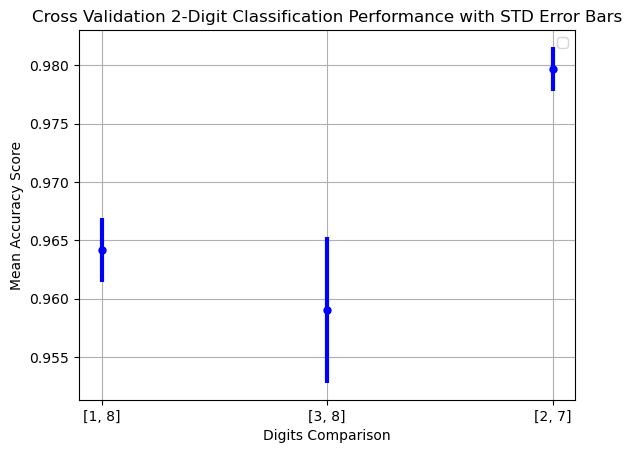

In [54]:
# plot cross validation scores for 2-digit


# Define x positions for training (left) and testing (right) 
x_train = np.arange(len(digits_set))  

# Plot with slight horizontal offsets for better visualization
plt.errorbar(x_train, meanscores_array, meanstd_array, fmt='.', linestyle='None', color='blue', markersize=10,elinewidth=3)
plt.legend()

# Adjust x-ticks to align with category labels
plt.xticks(np.arange(len(digits_set)), digits_set)

# Labels and title
plt.xlabel("Digits Comparison")
plt.ylabel("Mean Accuracy Score")
plt.title("Cross Validation 2-Digit Classification Performance with STD Error Bars")
plt.grid()

# save plot
plt.savefig(f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW3/Figures/dig2_classcompare_plot.png')

## Repeat for all the digits
### attempt adding trials

For all digits, using ridge score, the score of the training set is 0.8455333333333334
For all digits, using ridge score, the score of the training set is 0.8454166666666667
For all digits, using ridge score, the score of the training set is 0.8455333333333334
For all digits, using ridge score, the score of the training set is 0.8456333333333333
For all digits, using ridge score, the score of the training set is 0.84595
Ridge Tr Score Array [0.84553333 0.84541667 0.84553333 0.84563333 0.84595   ]
Ridge Te Score Array [0.8561 0.8562 0.857  0.8567 0.8569]
For all digits & alpha=1000.0, the cross validation mean of the training set is 0.9797104214151597 with an std of 0.0018761489744772706


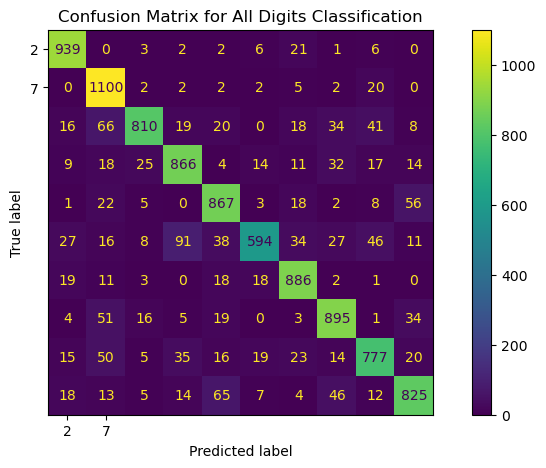

In [55]:

alphas = np.logspace(-3, 0, 100)
num_trials = 5
RidgeTr_score_array = np.zeros(num_trials)
RidgeTe_score_array = np.zeros(num_trials)

for trial in range(num_trials):
    # make ridge classifier and fit
    RidgeCL = RidgeClassifierCV(alphas=alphas)

    # refit PCA model 
    pca_K85_trial = PCA(n_components=K_85)
    Xtr_pca_K_trial = pca_K85_trial.fit_transform(Xtraindata.T)
    RidgeCL.fit(Xtr_pca_K_trial, ytrainlabels)

    # use ridge classifier score as a check for training
    ridgescore_tr = RidgeCL.score(Xtr_pca_K_trial, ytrainlabels)
    print(f'For all digits, using ridge score, the score of the training set is {ridgescore_tr}')

    # project data onto K-PC (59) modes
    Xte_pca_K_trial = pca_K85_trial.transform(Xtestdata.T)

    # use ridge classifier score as a check for testing
    ridgescore_te = RidgeCL.score(Xte_pca_K_trial, ytestlabels)

    # add train and test scores to an array
    RidgeTr_score_array[trial] = ridgescore_tr
    RidgeTe_score_array[trial] = ridgescore_te

print(f'Ridge Tr Score Array {RidgeTr_score_array}')
print(f'Ridge Te Score Array {RidgeTe_score_array}')
RidgeTr_score_mean = RidgeTr_score_array.mean()
RidgeTr_score_std = RidgeTr_score_array.std()

# use last trial's number to do cross val score and make confusion matrix
# find cross val score of training data
scores_tr = cross_val_score(RidgeCL, Xtr_pca_K_trial, ytrainlabels, cv=5)
# find mean and std
RidgeTr_CVscoremean = scores_tr.mean()
RidgeTr_CVscorestd = scores_tr.std()
print(f'For all digits & alpha={alpha}, the cross validation mean of the training set is {scoremean_tr} with an std of {scorestd_tr}')

# make confusion matrix
y_pred = RidgeCL.predict(Xte_pca_K)

fig, ax = plt.subplots(figsize=(10, 5))
ConfusionMatrixDisplay.from_predictions(ytestlabels, y_pred, ax=ax)
ax.set_xticks(range(len(digits))) 
ax.set_yticks(range(len(digits)))
ax.xaxis.set_ticklabels(digits)
ax.yaxis.set_ticklabels(digits)
_ = ax.set_title(
    f"Confusion Matrix for All Digits Classification"
)
plt.savefig(f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW3/Figures/Rclass_confmat_alldigits.png')


### Run KNN classification for training set with various K values, plot K valus vs accuracy

0.9735333333333334 accuracy with a standard deviation of 0.002020450994758902
0.9705833333333332 accuracy with a standard deviation of 0.0011726039399558561
0.9753833333333335 accuracy with a standard deviation of 0.0013044794619566018
0.9745000000000001 accuracy with a standard deviation of 0.0013844373104863418
0.9747333333333333 accuracy with a standard deviation of 0.0014106735979665722
0.9737666666666666 accuracy with a standard deviation of 0.001026590906295617
0.9736166666666666 accuracy with a standard deviation of 0.0010241527663824893
0.97285 accuracy with a standard deviation of 0.0005830951894845292
0.9724666666666668 accuracy with a standard deviation of 0.001203698005684549
0.9717833333333333 accuracy with a standard deviation of 0.0011200198410940704
0.9708166666666667 accuracy with a standard deviation of 0.001480803085416078
0.9703999999999999 accuracy with a standard deviation of 0.0011575836902790447
0.96965 accuracy with a standard deviation of 0.0012609520212918538

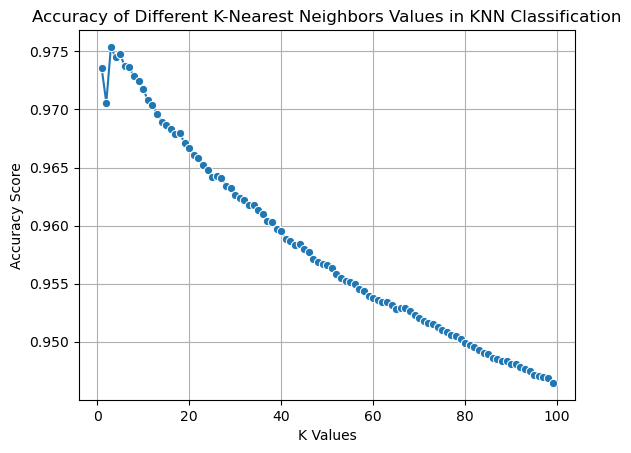

In [61]:
# Run KNN classification with all digits on train

k_values = [i for i in range(1,100)]
scores = []

for k in k_values:
    KNNCLk = KNeighborsClassifier(n_neighbors=k)
    scorescv = cross_val_score(KNNCLk, Xtr_pca_K, ytrainlabels,cv=5)
    print("{} accuracy with a standard deviation of {}".format(scorescv.mean(), scorescv.std()))
    scores.append(scorescv.mean())
k_KNN_best = np.argmax(scores)+1
print(k_KNN_best)

sns.lineplot(x = k_values, y = scores, marker = 'o')
plt.xlabel("K Values")
plt.ylabel("Accuracy Score")
plt.title("Accuracy of Different K-Nearest Neighbors Values in KNN Classification")
plt.grid()
plt.savefig("/Users/jadeg/Documents/UW/winter/AMATH 582/HW3/Figures/Ktest_KNNclass_tr.png")

### Run KNN class for testing set with various K values, plot K values vs accuracy

### use optimal K value from the training set, make confusion matrix for KNN

KNN Tr Score Array [0.98921667 0.98918333 0.98936667 0.98918333 0.98916667]
KNN Te Score Array [0.9756 0.9754 0.9756 0.9753 0.9753]


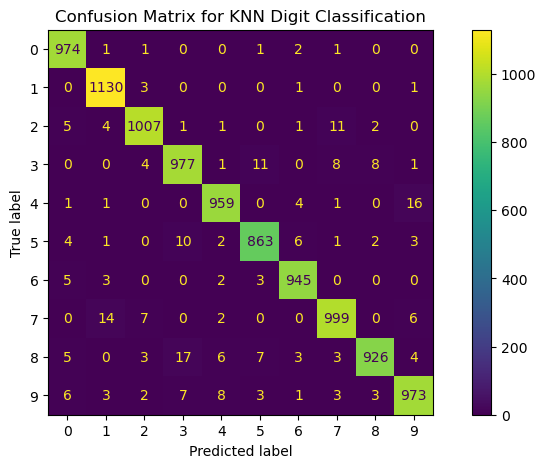

In [17]:
KNNTr_score_array = np.zeros(num_trials)
KNNTe_score_array = np.zeros(num_trials)
labs = [0,1,2,3,4,5,6,7,8,9]

for trial in range(num_trials):
    # refit PCA model 
    pca_K85_trial = PCA(n_components=K_85)
    Xtr_pca_K_trial = pca_K85_trial.fit_transform(Xtraindata.T)
    Xte_pca_K_trial = pca_K85_trial.transform(Xtestdata.T)

    # use optimal K value in KNN
    KNNCL = KNeighborsClassifier(n_neighbors=k_KNN_best)
    KNNCL.fit(Xtr_pca_K_trial, ytrainlabels)

    # find accuracy score
    KNNTr_score_array[trial] = KNNCL.score(Xtr_pca_K_trial, ytrainlabels)
    KNNTe_score_array[trial] = KNNCL.score(Xte_pca_K_trial, ytestlabels)

print(f'KNN Tr Score Array {KNNTr_score_array}')
print(f'KNN Te Score Array {KNNTe_score_array}')
KNNTr_score_mean = KNNTr_score_array.mean()
KNNTr_score_std = KNNTr_score_array.std()

# find score with cross val score
scores_tr = cross_val_score(KNNCL, Xtr_pca_K_trial, ytrainlabels, cv=5)
KNNTr_CVscoremean = scores_tr.mean()
KNNTr_CVscorestd = scores_tr.std()

y_pred_KNN = KNNCL.predict(Xte_pca_K_trial)

fig, ax = plt.subplots(figsize=(10, 5))
ConfusionMatrixDisplay.from_predictions(ytestlabels, y_pred_KNN, ax=ax)
ax.xaxis.set_ticklabels(labs)
ax.yaxis.set_ticklabels(labs)
_ = ax.set_title(
    f"Confusion Matrix for KNN Digit Classification"
)
plt.savefig(f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW3/Figures/KNNclass_confmat_{digits_set[-1]}')

### Apply LDA and make confusion matrix

LDA Tr Score Array [0.86658333 0.86656667 0.86653333 0.8665     0.8666    ]
LDA Te Score Array [0.8753 0.8751 0.8755 0.8755 0.8754]


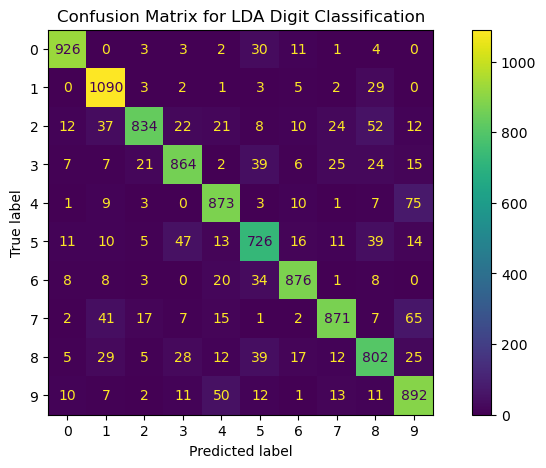

In [18]:
LDATr_score_array = np.zeros(num_trials)
LDATe_score_array = np.zeros(num_trials)
labs = [0,1,2,3,4,5,6,7,8,9]

for trial in range(num_trials):
    # refit PCA model 
    pca_K85_trial = PCA(n_components=K_85)
    Xtr_pca_K_trial = pca_K85_trial.fit_transform(Xtraindata.T)
    Xte_pca_K_trial = pca_K85_trial.transform(Xtestdata.T)

    # apply LDA
    # to training data
    LDACL = LinearDiscriminantAnalysis()
    LDACL.fit(Xtr_pca_K_trial, ytrainlabels)

    # find accuracy score
    LDATr_score_array[trial] = LDACL.score(Xtr_pca_K_trial, ytrainlabels)
    LDATe_score_array[trial] = LDACL.score(Xte_pca_K_trial, ytestlabels)

# calculate mean and std of trials accuracy scores
print(f'LDA Tr Score Array {LDATr_score_array}')
print(f'LDA Te Score Array {LDATe_score_array}')
LDATr_score_mean = LDATr_score_array.mean()
LDATr_score_std = LDATr_score_array.std()

# find score with cross val score
scores_tr = cross_val_score(LDACL, Xtr_pca_K_trial, ytrainlabels, cv=5)
LDATr_CVscoremean = scores_tr.mean()
LDATr_CVscorestd = scores_tr.std()

y_pred_LDA = LDACL.predict(Xte_pca_K_trial)

fig, ax = plt.subplots(figsize=(10, 5))
ConfusionMatrixDisplay.from_predictions(ytestlabels, y_pred_LDA, ax=ax)
ax.xaxis.set_ticklabels(labs)
ax.yaxis.set_ticklabels(labs)
_ = ax.set_title(
    f"Confusion Matrix for LDA Digit Classification"
)
plt.savefig(f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW3/Figures/LDAclass_confmat_{digits_set[-1]}')

## EXTRA CREDIT
### Implement SVM

SVM Tr Score Array [0.99195    0.99186667 0.99191667 0.99191667 0.9919    ]
SVM Te Score Array [0.9841 0.984  0.984  0.984  0.9841]


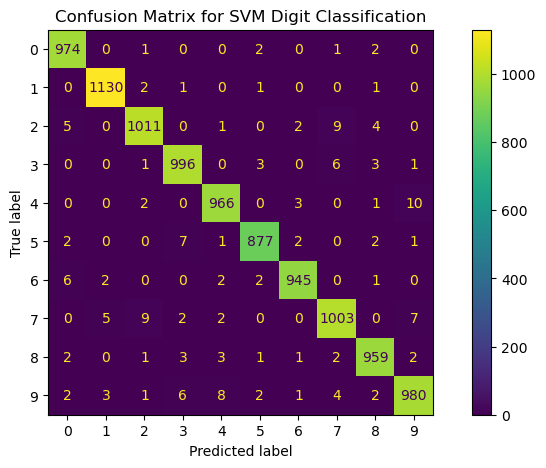

In [19]:
SVMTr_score_array = np.zeros(num_trials)
SVMTe_score_array = np.zeros(num_trials)
labs = [0,1,2,3,4,5,6,7,8,9]

for trial in range(num_trials):
    # refit PCA model 
    pca_K85_trial = PCA(n_components=K_85)
    Xtr_pca_K_trial = pca_K85_trial.fit_transform(Xtraindata.T)
    Xte_pca_K_trial = pca_K85_trial.transform(Xtestdata.T)

    SVMCL = SVC()
    SVMCL.fit(Xtr_pca_K_trial, ytrainlabels)

    # find accuracy score
    SVMTr_score_array[trial] = SVMCL.score(Xtr_pca_K_trial, ytrainlabels)
    SVMTe_score_array[trial] = SVMCL.score(Xte_pca_K_trial, ytestlabels)

# calculate mean and std of trials accuracy scores
print(f'SVM Tr Score Array {SVMTr_score_array}')
print(f'SVM Te Score Array {SVMTe_score_array}')
SVMTr_score_mean = SVMTr_score_array.mean()
SVMTr_score_std = SVMTr_score_array.std()

# find score with cross val score
scores_tr = cross_val_score(SVMCL, Xtr_pca_K_trial, ytrainlabels, cv=5)
SVMTr_CVscoremean = scores_tr.mean()
SVMTr_CVscorestd = scores_tr.std()

# Predict on test set
y_pred_SVM = SVMCL.predict(Xte_pca_K_trial)

fig, ax = plt.subplots(figsize=(10, 5))
ConfusionMatrixDisplay.from_predictions(ytestlabels, y_pred_SVM, ax=ax)
ax.xaxis.set_ticklabels(labs)
ax.yaxis.set_ticklabels(labs)
_ = ax.set_title(
    f"Confusion Matrix for SVM Digit Classification"
)
plt.savefig(f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW3/Figures/SVMclass_confmat_{digits_set[-1]}')

## Plot each of the cross validation score means and their std as error bars

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


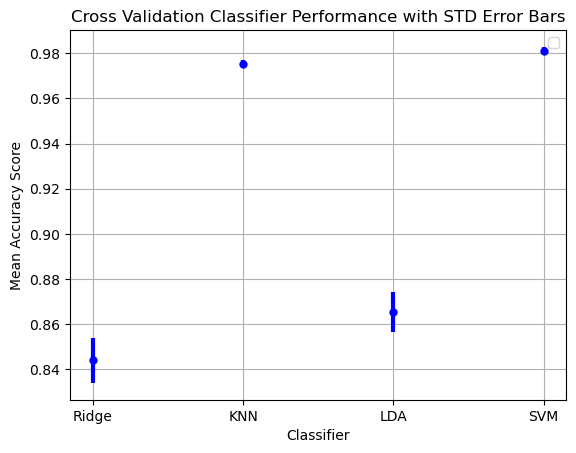

In [59]:

x_labels = np.array(['Ridge', 'KNN', 'LDA', 'SVM'])

# Define x positions for training (left) and testing (right) 
x_train = np.arange(len(x_labels))  

# Means for training and testing sets
y_train = np.array([RidgeTr_CVscoremean, KNNTr_CVscoremean, LDATr_CVscoremean, SVMTr_CVscoremean])

# Standard deviations for training and testing sets
e_train = np.array([RidgeTr_CVscorestd, KNNTr_CVscorestd, LDATr_CVscorestd, SVMTr_CVscorestd])

# Plot with slight horizontal offsets for better visualization
plt.errorbar(x_train, y_train, e_train, fmt='.', linestyle='None', color='blue', markersize=10,elinewidth=3)
plt.legend()

# Adjust x-ticks to align with category labels
plt.xticks(np.arange(len(x_labels)), x_labels)

# Labels and title
plt.xlabel("Classifier")
plt.ylabel("Mean Accuracy Score")
plt.title("Cross Validation Classifier Performance with STD Error Bars")
plt.grid()

# save plot
plt.savefig(f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW3/Figures/classcompare_plot_all')

## Plot each of the accuracies of each method

[1.81781309e-04 7.34846923e-05 3.59010987e-05 2.70801280e-05]
[3.65513338e-04 1.35646600e-04 1.49666295e-04 4.89897949e-05]


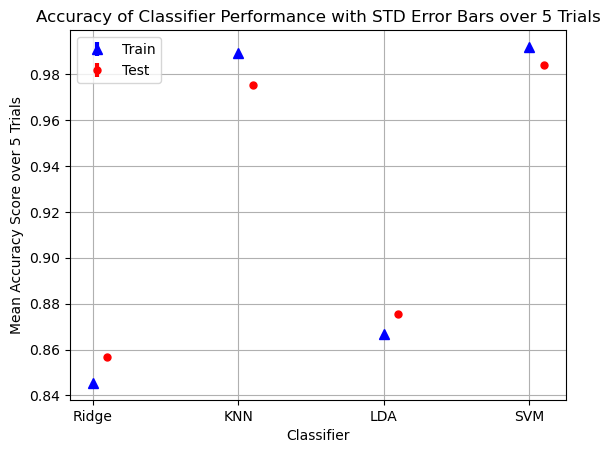

In [60]:

x_labels = np.array(['Ridge', 'KNN', 'LDA', 'SVM'])

# Define x positions for training (left) and testing (right) 
x_train = np.arange(len(x_labels))  # Shift left for train
x_test = np.arange(len(x_labels)) + 0.1   # Shift right for test

# Means for training and testing sets
y_train = np.array([RidgeTr_score_mean, KNNTr_score_mean, LDATr_score_mean, SVMTr_score_mean])
y_test = np.array([RidgeTe_score_array.mean(), KNNTe_score_array.mean(), LDATe_score_array.mean(), SVMTe_score_array.mean()])

# Standard deviations for training and testing sets
e_train = np.array([RidgeTr_score_std, KNNTr_score_std, LDATr_score_std, SVMTr_score_std])
print(e_train)
e_test = np.array([RidgeTe_score_array.std(), KNNTe_score_array.std(), LDATe_score_array.std(), SVMTe_score_array.std()])
print(e_test)

# Plot with slight horizontal offsets for better visualization
plt.errorbar(x_train, y_train, e_train, fmt='^', linestyle='None', label="Train", color='blue', markersize=7,elinewidth=3)
plt.errorbar(x_test, y_test, e_test, fmt='.', linestyle='None', label="Test", color='red', markersize=10,elinewidth=3)
plt.legend()

# Adjust x-ticks to align with category labels
plt.xticks(np.arange(len(x_labels)), x_labels)

# Labels and title
plt.xlabel("Classifier")
plt.ylabel("Mean Accuracy Score over 5 Trials")
plt.title("Accuracy of Classifier Performance with STD Error Bars over 5 Trials")
plt.legend()
plt.grid()

# save plot
plt.savefig(f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW3/Figures/acctrials_classcompare_plot_all')